# PART B — DATA ANALYSIS & TESTING TASKS

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import bernoulli
from scipy.stats import binom
from scipy.stats import poisson
from scipy.stats import lognorm
from scipy.stats import powerlaw

from scipy.stats import probplot
from scipy.stats import boxcox
from scipy.stats import zscore
from scipy.stats import norm

In [17]:
df = pd.read_csv(r"C:\Users\HP\Downloads\spread_locator_dataset - spread_locator_dataset.csv.csv")

df.head()

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success


Probability of Success: 1.0


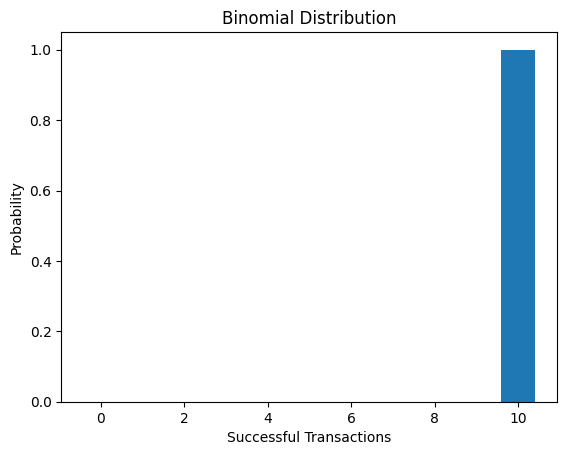

In [18]:
# Convert transaction status into binary values

df['status_binary'] = df['transaction_status'].map({
    'Success': 1,
    'Failed': 0
})

# Probability of success

p = df['status_binary'].mean()

print("Probability of Success:", p)


n = 10

x = np.arange(0, n+1)

binomial_pmf = binom.pmf(x, n, p)

plt.bar(x, binomial_pmf)

plt.title("Binomial Distribution")

plt.xlabel("Successful Transactions")

plt.ylabel("Probability")

plt.show()

Lambda: 2.8545454545454545


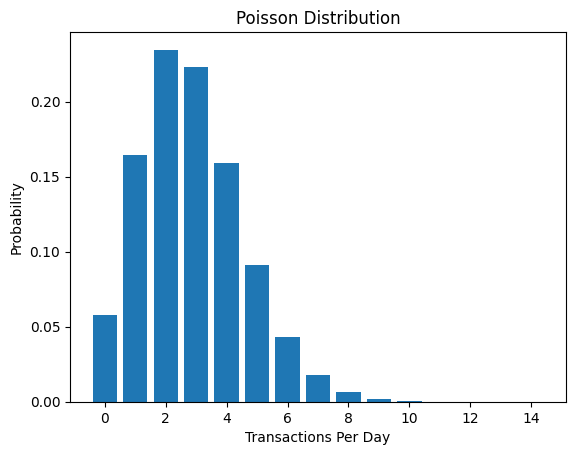

In [19]:
# Poisson Distribution

lambda_value = df['transaction_count'].mean()

print("Lambda:", lambda_value)

x = np.arange(0, 15)

poisson_pmf = poisson.pmf(x, lambda_value)

plt.bar(x, poisson_pmf)

plt.title("Poisson Distribution")

plt.xlabel("Transactions Per Day")

plt.ylabel("Probability")

plt.show()

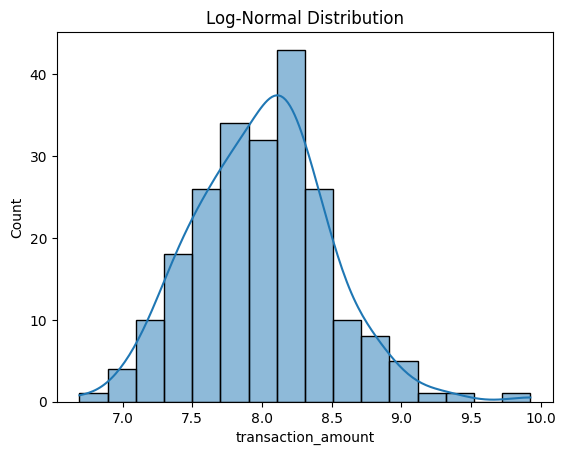

In [20]:
# Log-Normal Distribution

log_data = np.log(df['transaction_amount'])

sns.histplot(log_data, kde=True)

plt.title("Log-Normal Distribution")

plt.show()

In [21]:
# Power Law Distribution

params = powerlaw.fit(df['transaction_amount'])

print(params)


(np.float64(0.41232325172331613), np.float64(804.4199999999998), np.float64(19658.420000000006))


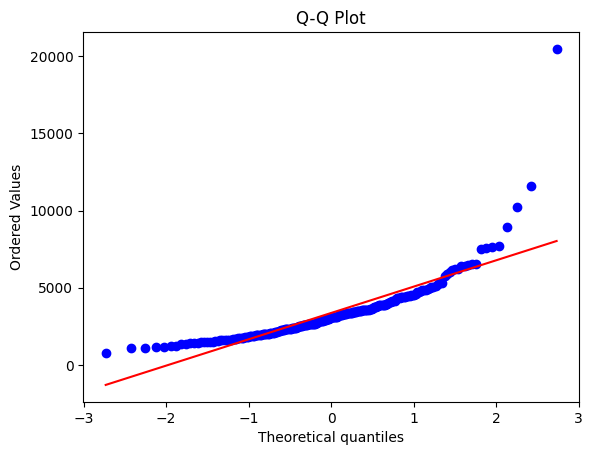

In [22]:
# Q-Q Plot to Test Normality

probplot(df['transaction_amount'], dist='norm', plot=plt)

plt.title("Q-Q Plot")

plt.show()

Lambda: -0.18083391951050778


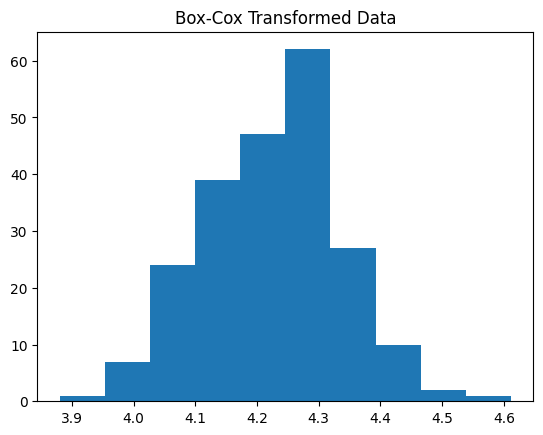

In [23]:
# Box-Cox Transform to Stabilize Variance


transformed_data, lambda_value = boxcox(df['transaction_amount'])

print("Lambda:", lambda_value)

plt.hist(transformed_data, bins=10)

plt.title("Box-Cox Transformed Data")

plt.show()

In [24]:
# Z-score measures how far a value is from mean


df['z_score'] = zscore(df['transaction_amount'])

print(df[['transaction_amount','z_score']])

from scipy.stats import norm

mean = df['transaction_amount'].mean()

std = df['transaction_amount'].std()

z = (5000 - mean) / std

probability = 1 - norm.cdf(z)

print("Probability:", probability)

     transaction_amount   z_score
0               3821.34  0.230240
1               2781.84 -0.294446
2               4120.97  0.381477
3               6383.78  1.523626
4               2651.61 -0.360179
..                  ...       ...
215             4356.76  0.500492
216             2025.53 -0.676192
217             2648.08 -0.361961
218             2338.62 -0.518160
219             3105.52 -0.131069

[220 rows x 2 columns]
Probability: 0.20517209567554384


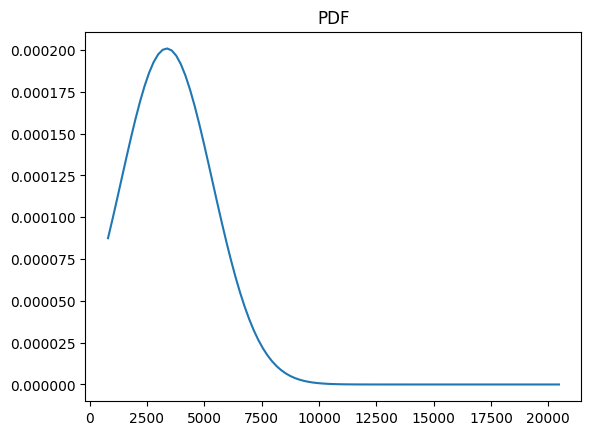

In [25]:
# PDF and CDF for Transaction Amounts

x = np.linspace(
    df['transaction_amount'].min(),
    df['transaction_amount'].max(),
    100
)

mean = df['transaction_amount'].mean()

std = df['transaction_amount'].std()

pdf = norm.pdf(x, mean, std)

plt.plot(x, pdf)

plt.title("PDF")

plt.show()

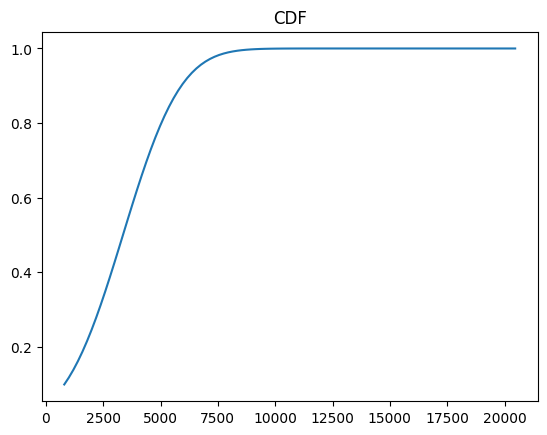

In [26]:
# CDF shows cumulative probability

cdf = norm.cdf(x, mean, std)

plt.plot(x, cdf)

plt.title("CDF")

plt.show()

# PART A — THEORETICAL FOUNDATION


1. What is Statistical Distribution?

A statistical distribution describes how data values are spread across different ranges. It helps understand patterns, probabilities, and behavior of data.

Example

Customer transaction amounts:

Most customers spend ₹1000–₹3000
Few customers spend ₹10000+

This spread of values forms a distribution.

Types
Normal Distribution
Bernoulli Distribution
Binomial Distribution
Poisson Distribution
Log-Normal Distribution
Importance
Helps in prediction
Identifies trends
Used in machine learning and statistics

2. What is a Q-Q Plot and Why is it Used?

Q-Q (Quantile-Quantile) Plot compares dataset distribution with normal distribution.

It checks whether data follows a normal distribution.

Interpretation
Straight line → Normally distributed
Curved line → Not normal
Uses
Check normality
Detect skewness
Detect outliers

3. Difference Between Discrete and Continuous Distribution
Discrete Distribution	Continuous Distribution
Countable values	Infinite values
Example: Number of transactions	Example: Transaction amount
Uses integers	Uses decimal values
Example
Discrete → 5 transactions/day
Continuous → ₹2450.75 transaction amount
4. What is Bernoulli Distribution?

Bernoulli distribution has only two outcomes:

Success = 1
Failure = 0
Formula

P(X=x)=px(1−p)1−x

Example

Transaction Status:

Success
Fail
Use

Used for binary classification problems.

5. What is Binomial Distribution?

Binomial distribution represents number of successes in multiple trials.

Conditions
Fixed number of trials
Two outcomes
Same probability

Example

Out of 10 transactions:

Probability of 7 successful transactions


6. Explain Log-Normal Distribution

If logarithm of data follows normal distribution, then original data is Log-Normal.

Characteristics
Right-skewed
Large values possible
Common in financial data
Example

Transaction amounts, stock prices, salaries.

Why Used?

Many e-commerce transaction datasets follow Log-Normal distribution.

7. Explain Power Law Distribution

Power Law distribution contains many small values and few extremely large values.

Characteristics
Heavy tail
Rare large events
Example
Very few customers spend huge amounts
Social media followers
Importance

Helps detect high-value customers.

8. What is Box-Cox Transformation?

Box-Cox transformation converts non-normal data into near-normal data.

Used to stabilize variance and improve model performance.

Uses
Reduces skewness
Improves normality


9. Explain Poisson Distribution with Example

Poisson distribution models count of events occurring in fixed interval.

Example

Number of transactions per day.

Uses
Event counting
Call arrivals
Website visits

10. What is Z-score Probability?

Z-score measures how far a value is from mean.

Example

Checking whether ₹5000 transaction is unusually high.

11. Difference Between PDF and CDF

PDF	

Probability Density Function	
Gives density at point	
Used in continuous distribution	

CDF

Cumulative Distribution Function
Gives cumulative probability
Used for total probability
